# My work. Hopefully it doesn't disappoint!

#### All Imports will be up here

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

#### Setting up the Dataset

In [42]:
data = pd.read_csv('data/bank-additional.csv')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


#### Initial Observations on Data

In [43]:
#Basic information about the dataset
number_of_observations = data.shape[0]
number_of_features = data.shape[1]
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
categorial_features = data.select_dtypes(include=['str']).columns

print(f"Number of observations: {number_of_observations}")
print(f"Number of features: {number_of_features}")
print(f"Numerical features: {numerical_features}")
print(f"Categorial features: {categorial_features}")

Number of observations: 4119
Number of features: 21
Numerical features: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')
Categorial features: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


**Space for your analysis and observations on the relationships between features and the target variable.**

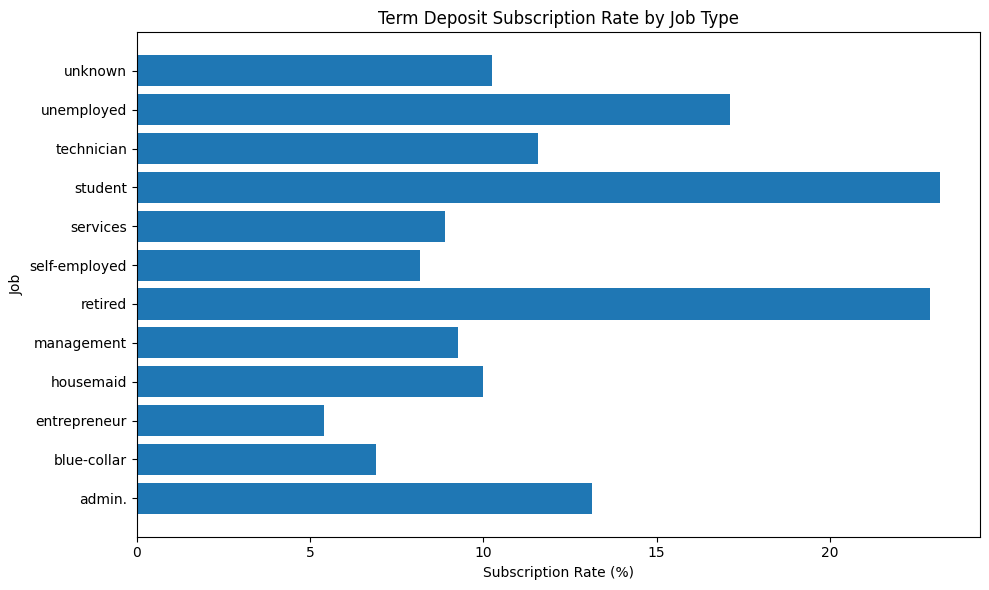

In [44]:
# Subscription rate by job type
job_y_rate = data.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
plt.figure(figsize=(10, 6))
plt.barh(job_y_rate.index, job_y_rate.values)
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')
plt.title('Term Deposit Subscription Rate by Job Type')
plt.tight_layout()
plt.show()

#### Feature Relationships with Target Variable

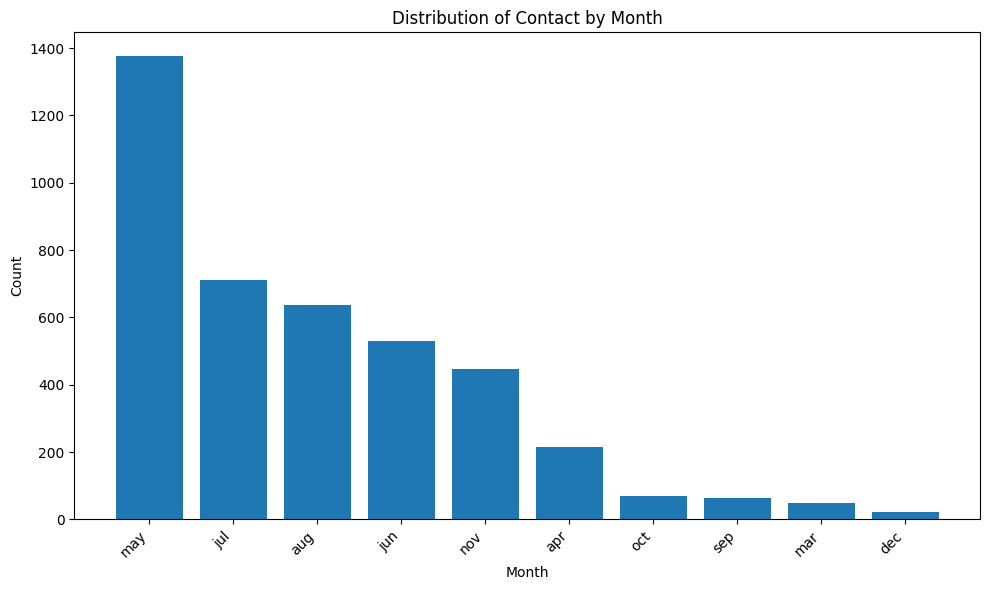

In [45]:
# Month when contact was made
plt.figure(figsize=(10, 6))
plt.bar(data.month.value_counts().index, data.month.value_counts().values)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title("Distribution of Contact by Month")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

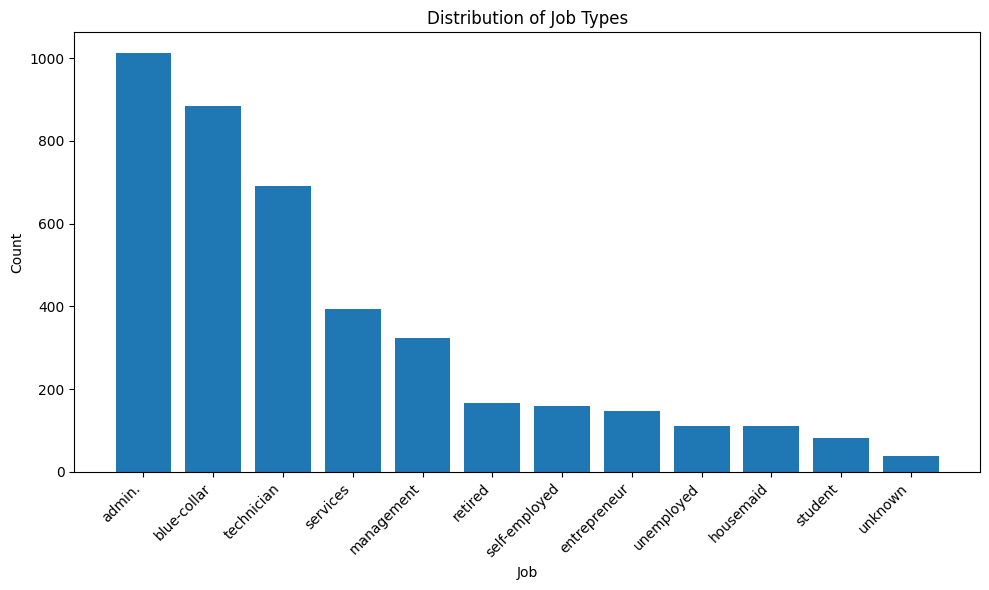

In [46]:
# Job distribution
plt.figure(figsize=(10, 6))
plt.bar(data.job.value_counts().index, data.job.value_counts().values)
plt.xlabel('Job')
plt.ylabel('Count')
plt.title("Distribution of Job Types")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

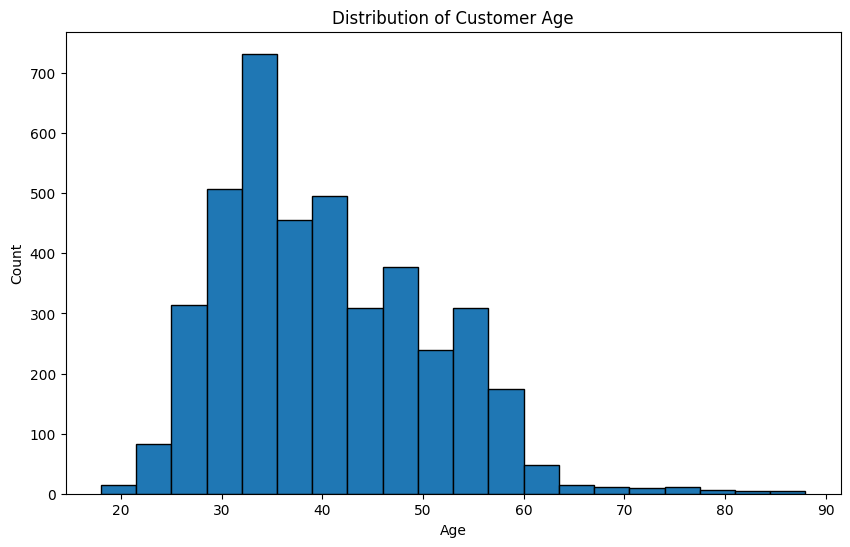

In [47]:
# Age distribution
plt.figure(figsize=(10, 6))
plt.hist(data.age, bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title("Distribution of Customer Age")
plt.show()

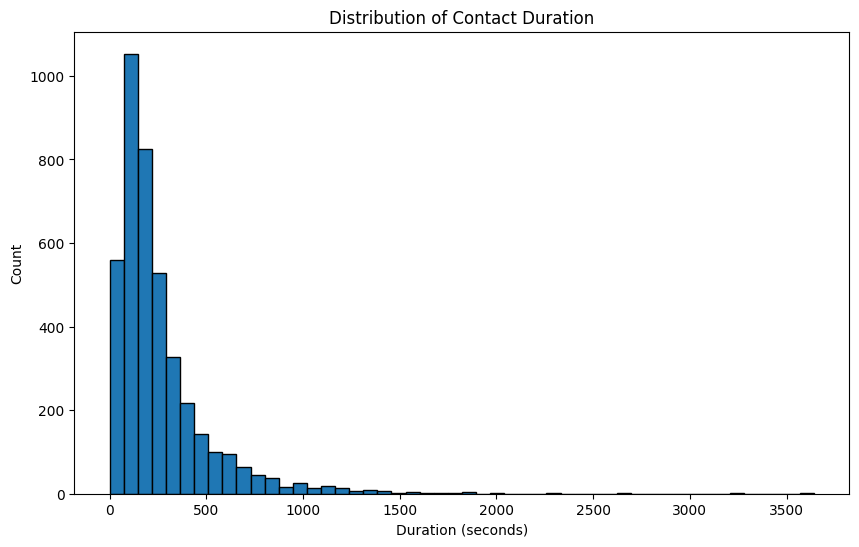

In [48]:
# Duration distribution
plt.figure(figsize=(10, 6))
plt.hist(data.duration, bins=50, edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title("Distribution of Contact Duration")
plt.show()

#### Feature Distributions

In [50]:
# Define what values represent missing data in each feature
missing_data = {
    'job': 'unknown',
    'marital': 'unknown',
    'education': 'unknown',
    'default': 'unknown',
    'housing': 'unknown',
    'loan': 'unknown',
    'pdays': 999,
    'poutcome': 'nonexistent',
}

# Convert missing value markers to pd.NA for standardization
data = data.replace(missing_data, pd.NA)

In [51]:
# Convert missing value markers to pd.NA for standardization
data = data.replace(missing_data, pd.NA)
# Create summary of missing values
missing_summary = []

for col in data.columns:
    missing_count = data[col].isna().sum()
    
    if missing_count > 0:
        missing_pct = (missing_count / len(data)) * 100
        missing_type = missing_data.get(col, 'N/A')
        
        missing_summary.append({
            'Column': col,
            'Missing_Type': missing_type,
            'Count': missing_count,
            'Percentage': f'{missing_pct:.1f}%'
        })

missing_df = pd.DataFrame(missing_summary)
display(missing_df)


,Column,Missing_Type,Count,Percentage
0,job,unknown,39,0.9%
1,marital,unknown,11,0.3%
2,education,unknown,167,4.1%
3,default,unknown,803,19.5%
4,housing,unknown,105,2.5%
5,loan,unknown,105,2.5%
6,pdays,999,3959,96.1%
7,poutcome,nonexistent,3523,85.5%


#### Missing Values Analysis

**Observation:** The target variable is heavily skewed towards 'no', indicating significant class imbalance that will need to be addressed in future modeling steps.

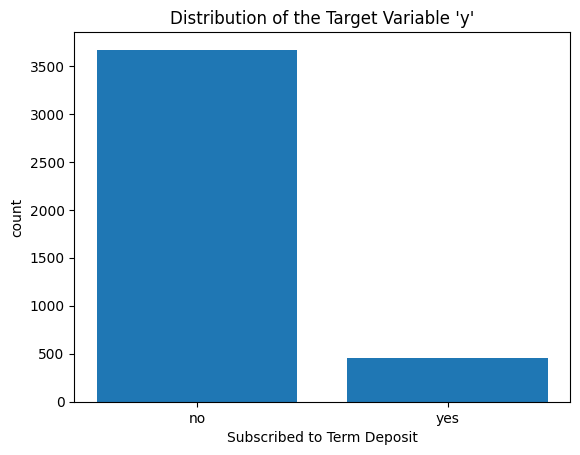

In [52]:
plt.bar(data.y.value_counts().index, data.y.value_counts().values)
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('count')
plt.title("Distribution of the Target Variable 'y'")
plt.show()

#### Target Variable Distribution

#### Next Steps

Key observations to address:
- Class imbalance in target variable
- Substantial missing values in several features
- Explore more feature relationships and correlations